#Goal: Identify factors contributing to 30-day hospital readmissions and potential cost leakage using exploratory data analysis.

#Pandas – Data handling (MOST important)
Used for:
Reading CSV,
Cleaning missing values,
Filtering patients,
Grouping & aggregation

In [2]:
pip install pandas

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


#NumPy – Numerical operations
Used for:
Calculations,
Handling NaN values,
Performance boost
#The math engine for python

In [3]:
pip install numpy

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


#Matplotlib – Basic visualizations
Used for:
Bar charts,
Line plots,
Distribution plots

In [4]:
pip install matplotlib.pyplot

Note: you may need to restart the kernel to use updated packages.


ERROR: Could not find a version that satisfies the requirement matplotlib.pyplot (from versions: none)

[notice] A new release of pip is available: 25.1.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip
ERROR: No matching distribution found for matplotlib.pyplot


#Seaborn – Advanced & beautiful plots
Used for:
Heatmaps,
Readmission comparisons,
Statistical plots

In [5]:
pip install seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Scikit-Learn (sklearn) – Prediction & ML
Used for:
Readmission prediction,
Logistic Regression,
Decision Trees,
Model evaluation

In [6]:
pip install Scikit-Learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression


In [9]:
plt.style.use("default")

#Reading the actual data file
#We have chosen very relevent columns only because we are focusing on the readmission rate and cost leakage so we need those attributes only which will affect the readmission rate

In [10]:
important_cols=[
'encounter_id',
'race',
'gender',
'age',
'admission_type_id',
'discharge_disposition_id',
'admission_source_id',
'time_in_hospital',
'num_lab_procedures',
'num_procedures',
'num_medications',
'number_outpatient',
'number_emergency',
'number_inpatient',
'number_diagnoses',
'insulin',
'readmitted'
]
df=pd.read_csv("diabetic_data.csv",usecols=important_cols)

The dataset contains 101766 patient visits with 16 clinical and administrative features.

In [11]:
df.shape

(101766, 17)

In [12]:
df.head()

,encounter_id,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses,insulin,readmitted
0,2278392,Caucasian,Female,[0-10),6,25,1,1,41,0,1,0,0,0,1,No,NO
1,149190,Caucasian,Female,[10-20),1,1,7,3,59,0,18,0,0,0,9,Up,>30
2,64410,AfricanAmerican,Female,[20-30),1,1,7,2,11,5,13,2,0,1,6,No,NO
3,500364,Caucasian,Male,[30-40),1,1,7,2,44,1,16,0,0,0,7,Up,NO
4,16680,Caucasian,Male,[40-50),1,1,7,1,51,0,8,0,0,0,5,Steady,NO


In [13]:
df.columns

Index(['encounter_id', 'race', 'gender', 'age', 'admission_type_id',
       'discharge_disposition_id', 'admission_source_id', 'time_in_hospital',
       'num_lab_procedures', 'num_procedures', 'num_medications',
       'number_outpatient', 'number_emergency', 'number_inpatient',
       'number_diagnoses', 'insulin', 'readmitted'],
      dtype='str')

In [14]:
df.dtypes

encounter_id                int64
race                          str
gender                        str
age                           str
admission_type_id           int64
discharge_disposition_id    int64
admission_source_id         int64
time_in_hospital            int64
num_lab_procedures          int64
num_procedures              int64
num_medications             int64
number_outpatient           int64
number_emergency            int64
number_inpatient            int64
number_diagnoses            int64
insulin                       str
readmitted                    str
dtype: object

Several features contain missing values, especially in diagnosis-related columns. Missing value treatment will be handled after EDA.

#No missing values

In [15]:
df.replace("?", np.nan, inplace=True)

,encounter_id,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses,insulin,readmitted
0,2278392,Caucasian,Female,[0-10),6,25,1,1,41,0,1,0,0,0,1,No,NO
1,149190,Caucasian,Female,[10-20),1,1,7,3,59,0,18,0,0,0,9,Up,>30
2,64410,AfricanAmerican,Female,[20-30),1,1,7,2,11,5,13,2,0,1,6,No,NO
3,500364,Caucasian,Male,[30-40),1,1,7,2,44,1,16,0,0,0,7,Up,NO
4,16680,Caucasian,Male,[40-50),1,1,7,1,51,0,8,0,0,0,5,Steady,NO
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
101761,443847548,AfricanAmerican,Male,[70-80),1,3,7,3,51,0,16,0,0,0,9,Down,>30
101762,443847782,AfricanAmerican,Female,[80-90),1,4,5,5,33,3,18,0,0,1,9,Steady,NO
101763,443854148,Caucasian,Male,[70-80),1,1,7,1,53,0,9,1,0,0,13,Down,NO
101764,443857166,Caucasian,Female,[80-90),2,3,7,10,45,2,21,0,0,1,9,Up,NO


In [16]:
df.isnull().sum()

encounter_id                   0
race                        2273
gender                         0
age                            0
admission_type_id              0
discharge_disposition_id       0
admission_source_id            0
time_in_hospital               0
num_lab_procedures             0
num_procedures                 0
num_medications                0
number_outpatient              0
number_emergency               0
number_inpatient               0
number_diagnoses               0
insulin                        0
readmitted                     0
dtype: int64

In [17]:
df['race'] = df['race'].fillna('Unknown')

In [18]:
df.head(20)

,encounter_id,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses,insulin,readmitted
0,2278392,Caucasian,Female,[0-10),6,25,1,1,41,0,1,0,0,0,1,No,NO
1,149190,Caucasian,Female,[10-20),1,1,7,3,59,0,18,0,0,0,9,Up,>30
2,64410,AfricanAmerican,Female,[20-30),1,1,7,2,11,5,13,2,0,1,6,No,NO
3,500364,Caucasian,Male,[30-40),1,1,7,2,44,1,16,0,0,0,7,Up,NO
4,16680,Caucasian,Male,[40-50),1,1,7,1,51,0,8,0,0,0,5,Steady,NO
5,35754,Caucasian,Male,[50-60),2,1,2,3,31,6,16,0,0,0,9,Steady,>30
6,55842,Caucasian,Male,[60-70),3,1,2,4,70,1,21,0,0,0,7,Steady,NO
7,63768,Caucasian,Male,[70-80),1,1,7,5,73,0,12,0,0,0,8,No,>30
8,12522,Caucasian,Female,[80-90),2,1,4,13,68,2,28,0,0,0,8,Steady,NO
9,15738,Caucasian,Female,[90-100),3,3,4,12,33,3,18,0,0,0,8,Steady,NO


In [19]:
df.duplicated().sum()

np.int64(0)

#Target Variable

In [20]:
df['readmitted'].value_counts()

readmitted
NO     54864
>30    35545
<30    11357
Name: count, dtype: int64

#Adding new column readmitted_binary consisting of 0 and 1's only for easy analysis

In [21]:
df['readmitted_binary']=df['readmitted'].apply(lambda x:1 if x=='<30' else 0)

In [22]:
df.columns

Index(['encounter_id', 'race', 'gender', 'age', 'admission_type_id',
       'discharge_disposition_id', 'admission_source_id', 'time_in_hospital',
       'num_lab_procedures', 'num_procedures', 'num_medications',
       'number_outpatient', 'number_emergency', 'number_inpatient',
       'number_diagnoses', 'insulin', 'readmitted', 'readmitted_binary'],
      dtype='str')

In [23]:
df['readmitted_binary'].value_counts()

readmitted_binary
0    90409
1    11357
Name: count, dtype: int64

Target Distribution
1)It shows the percentage distribution of your target variable
i.e. how many patients were readmitted vs not readmitted.
**Only ~11% of patients are readmitted within 30 days, indicating a strong class imbalance.

normalize=True is for giving proportions instead of raw counts and 100 converts it into percentage


In [24]:
df['readmitted_binary'].value_counts(normalize=True) * 100

readmitted_binary
0    88.840084
1    11.159916
Name: proportion, dtype: float64

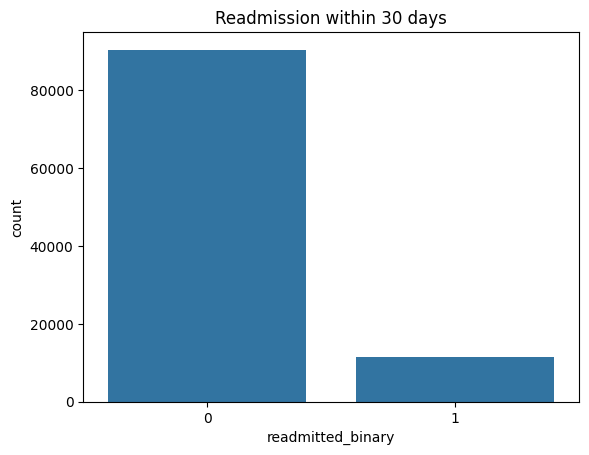

In [25]:
sb.countplot(x='readmitted_binary', data=df)
plt.title("Readmission within 30 days")
plt.show()

In [26]:
df['age'].value_counts().sort_index()

age
[0-10)        161
[10-20)       691
[20-30)      1657
[30-40)      3775
[40-50)      9685
[50-60)     17256
[60-70)     22483
[70-80)     26068
[80-90)     17197
[90-100)     2793
Name: count, dtype: int64

To get the number of readmitted and non readmitted patients from each group

In [27]:
age_readmit=df.groupby('age')['readmitted_binary'].value_counts()
age_readmit

age       readmitted_binary
[0-10)    0                      158
          1                        3
[10-20)   0                      651
          1                       40
[20-30)   0                     1421
          1                      236
[30-40)   0                     3351
          1                      424
[40-50)   0                     8658
          1                     1027
[50-60)   0                    15588
          1                     1668
[60-70)   0                    19981
          1                     2502
[70-80)   0                    22999
          1                     3069
[80-90)   0                    15119
          1                     2078
[90-100)  0                     2483
          1                      310
Name: count, dtype: int64

\Older age groups show a higher readmission rate, indicating increased risk among elderly patients.

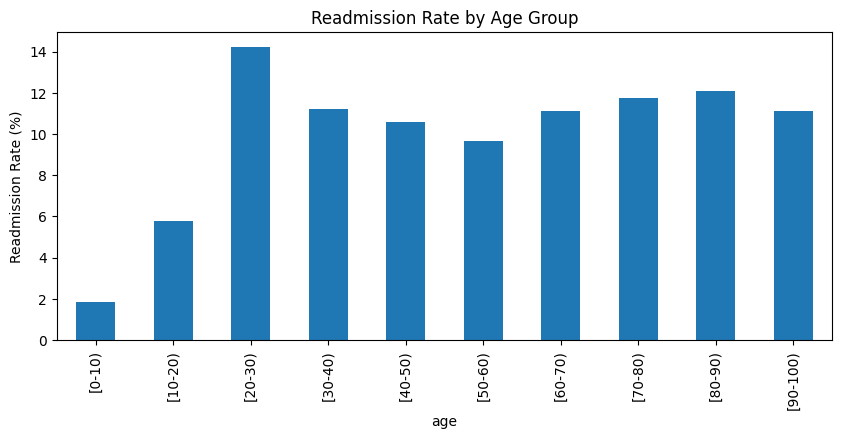

In [28]:
age_readmit=df.groupby('age')['readmitted_binary'].mean()*100
age_readmit.plot(kind='bar',figsize=(10,4))
plt.ylabel("Readmission Rate (%)")
plt.title("Readmission Rate by Age Group")
plt.show()

In [29]:
gender_readmit=df.groupby('gender')['readmitted_binary'].value_counts()
gender_readmit


gender           readmitted_binary
Female           0                    48556
                 1                     6152
Male             0                    41850
                 1                     5205
Unknown/Invalid  0                        3
Name: count, dtype: int64

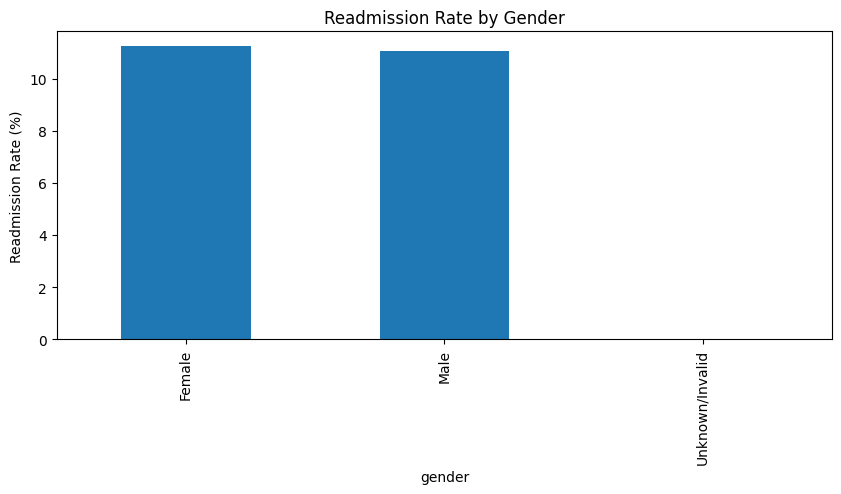

In [30]:
gender_readmit=df.groupby('gender')['readmitted_binary'].mean()*100
gender_readmit.plot(kind='bar',figsize=(10,4))
plt.ylabel("Readmission Rate (%)")
plt.title("Readmission Rate by Gender")
plt.show()

In [31]:
df1 = pd.read_csv('IDS_mapping.csv',header=None)

In [32]:
admission_type_map = (
    df1.iloc[1:9]
    .rename(columns={0: 'admission_type_id', 1: 'description'})
    .dropna()
    .drop_duplicates()
)

admission_type_map['admission_type_id'] = admission_type_map['admission_type_id'].astype(str)
admission_type_map

,admission_type_id,description
1,1,Emergency
2,2,Urgent
3,3,Elective
4,4,Newborn
5,5,Not Available
7,7,Trauma Center
8,8,Not Mapped


In [33]:
discharge_map = (
    df1.iloc[11:41]
    .rename(columns={0: 'discharge_disposition_id', 1: 'description'})
    .dropna()
    .drop_duplicates()
)

discharge_map['discharge_disposition_id'] = discharge_map['discharge_disposition_id'].astype(str)
discharge_map


,discharge_disposition_id,description
11,1,Discharged to home
12,2,Discharged/transferred to another short term h...
13,3,Discharged/transferred to SNF
14,4,Discharged/transferred to ICF
15,5,Discharged/transferred to another type of inpa...
16,6,Discharged/transferred to home with home healt...
17,7,Left AMA
18,8,Discharged/transferred to home under care of H...
19,9,Admitted as an inpatient to this hospital
20,10,Neonate discharged to another hospital for neo...


In [34]:
source_map = (
    df1.iloc[43:68]
    .rename(columns={0: 'admission_source_id', 1: 'description'})
    .dropna()
    .drop_duplicates()
)

source_map['admission_source_id'] = source_map['admission_source_id'].astype(str)
source_map


,admission_source_id,description
43,1,Physician Referral
44,2,Clinic Referral
45,3,HMO Referral
46,4,Transfer from a hospital
47,5,Transfer from a Skilled Nursing Facility (SNF)
48,6,Transfer from another health care facility
49,7,Emergency Room
50,8,Court/Law Enforcement
51,9,Not Available
52,10,Transfer from critial access hospital


In [35]:
admission_type_map = admission_type_map.rename(
    columns={'description': 'admission_type_desc'}
)


discharge_map = discharge_map.rename(
    columns={'description': 'discharge_desc'}
)

source_map = source_map.rename(
    columns={'description': 'admission_source_desc'}
)
admission_type_map




,admission_type_id,admission_type_desc
1,1,Emergency
2,2,Urgent
3,3,Elective
4,4,Newborn
5,5,Not Available
7,7,Trauma Center
8,8,Not Mapped


In [36]:
discharge_map

,discharge_disposition_id,discharge_desc
11,1,Discharged to home
12,2,Discharged/transferred to another short term h...
13,3,Discharged/transferred to SNF
14,4,Discharged/transferred to ICF
15,5,Discharged/transferred to another type of inpa...
16,6,Discharged/transferred to home with home healt...
17,7,Left AMA
18,8,Discharged/transferred to home under care of H...
19,9,Admitted as an inpatient to this hospital
20,10,Neonate discharged to another hospital for neo...


In [37]:
source_map

,admission_source_id,admission_source_desc
43,1,Physician Referral
44,2,Clinic Referral
45,3,HMO Referral
46,4,Transfer from a hospital
47,5,Transfer from a Skilled Nursing Facility (SNF)
48,6,Transfer from another health care facility
49,7,Emergency Room
50,8,Court/Law Enforcement
51,9,Not Available
52,10,Transfer from critial access hospital


In [38]:
for col in ['admission_type_id',
            'discharge_disposition_id',
            'admission_source_id']:
    df[col] = df[col].astype(str)

df = df.merge(discharge_map, on='discharge_disposition_id', how='left')
df = df.merge(admission_type_map, on='admission_type_id', how='left')
df = df.merge(source_map, on='admission_source_id', how='left')


In [39]:
df

,encounter_id,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,...,number_outpatient,number_emergency,number_inpatient,number_diagnoses,insulin,readmitted,readmitted_binary,discharge_desc,admission_type_desc,admission_source_desc
0,2278392,Caucasian,Female,[0-10),6,25,1,1,41,0,...,0,0,0,1,No,NO,0,Not Mapped,NaN,Physician Referral
1,149190,Caucasian,Female,[10-20),1,1,7,3,59,0,...,0,0,0,9,Up,>30,0,Discharged to home,Emergency,Emergency Room
2,64410,AfricanAmerican,Female,[20-30),1,1,7,2,11,5,...,2,0,1,6,No,NO,0,Discharged to home,Emergency,Emergency Room
3,500364,Caucasian,Male,[30-40),1,1,7,2,44,1,...,0,0,0,7,Up,NO,0,Discharged to home,Emergency,Emergency Room
4,16680,Caucasian,Male,[40-50),1,1,7,1,51,0,...,0,0,0,5,Steady,NO,0,Discharged to home,Emergency,Emergency Room
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
101761,443847548,AfricanAmerican,Male,[70-80),1,3,7,3,51,0,...,0,0,0,9,Down,>30,0,Discharged/transferred to SNF,Emergency,Emergency Room
101762,443847782,AfricanAmerican,Female,[80-90),1,4,5,5,33,3,...,0,0,1,9,Steady,NO,0,Discharged/transferred to ICF,Emergency,Transfer from a Skilled Nursing Facility (SNF)
101763,443854148,Caucasian,Male,[70-80),1,1,7,1,53,0,...,1,0,0,13,Down,NO,0,Discharged to home,Emergency,Emergency Room
101764,443857166,Caucasian,Female,[80-90),2,3,7,10,45,2,...,0,0,1,9,Up,NO,0,Discharged/transferred to SNF,Urgent,Emergency Room


In [40]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 21 columns):
 #   Column                    Non-Null Count   Dtype
---  ------                    --------------   -----
 0   encounter_id              101766 non-null  int64
 1   race                      101766 non-null  str  
 2   gender                    101766 non-null  str  
 3   age                       101766 non-null  str  
 4   admission_type_id         101766 non-null  str  
 5   discharge_disposition_id  101766 non-null  str  
 6   admission_source_id       101766 non-null  str  
 7   time_in_hospital          101766 non-null  int64
 8   num_lab_procedures        101766 non-null  int64
 9   num_procedures            101766 non-null  int64
 10  num_medications           101766 non-null  int64
 11  number_outpatient         101766 non-null  int64
 12  number_emergency          101766 non-null  int64
 13  number_inpatient          101766 non-null  int64
 14  number_diagnoses          10176

#I transformed raw ID-coded healthcare data into an analysis-ready dataset by normalizing and merging lookup tables.”

In [41]:
df

,encounter_id,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,...,number_outpatient,number_emergency,number_inpatient,number_diagnoses,insulin,readmitted,readmitted_binary,discharge_desc,admission_type_desc,admission_source_desc
0,2278392,Caucasian,Female,[0-10),6,25,1,1,41,0,...,0,0,0,1,No,NO,0,Not Mapped,NaN,Physician Referral
1,149190,Caucasian,Female,[10-20),1,1,7,3,59,0,...,0,0,0,9,Up,>30,0,Discharged to home,Emergency,Emergency Room
2,64410,AfricanAmerican,Female,[20-30),1,1,7,2,11,5,...,2,0,1,6,No,NO,0,Discharged to home,Emergency,Emergency Room
3,500364,Caucasian,Male,[30-40),1,1,7,2,44,1,...,0,0,0,7,Up,NO,0,Discharged to home,Emergency,Emergency Room
4,16680,Caucasian,Male,[40-50),1,1,7,1,51,0,...,0,0,0,5,Steady,NO,0,Discharged to home,Emergency,Emergency Room
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
101761,443847548,AfricanAmerican,Male,[70-80),1,3,7,3,51,0,...,0,0,0,9,Down,>30,0,Discharged/transferred to SNF,Emergency,Emergency Room
101762,443847782,AfricanAmerican,Female,[80-90),1,4,5,5,33,3,...,0,0,1,9,Steady,NO,0,Discharged/transferred to ICF,Emergency,Transfer from a Skilled Nursing Facility (SNF)
101763,443854148,Caucasian,Male,[70-80),1,1,7,1,53,0,...,1,0,0,13,Down,NO,0,Discharged to home,Emergency,Emergency Room
101764,443857166,Caucasian,Female,[80-90),2,3,7,10,45,2,...,0,0,1,9,Up,NO,0,Discharged/transferred to SNF,Urgent,Emergency Room


In [42]:

df[['admission_type_desc',
    'discharge_desc',
    'admission_source_desc']].isna().sum()


admission_type_desc      5291
discharge_desc           3691
admission_source_desc    6781
dtype: int64

#Upto here we are done with data preparation
#Post-merge sanity checks(mandatory)

Q)Does discharge disposition affect readmission?#Readmission rate by discharge type

In [43]:
df.info()
df

<class 'pandas.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 21 columns):
 #   Column                    Non-Null Count   Dtype
---  ------                    --------------   -----
 0   encounter_id              101766 non-null  int64
 1   race                      101766 non-null  str  
 2   gender                    101766 non-null  str  
 3   age                       101766 non-null  str  
 4   admission_type_id         101766 non-null  str  
 5   discharge_disposition_id  101766 non-null  str  
 6   admission_source_id       101766 non-null  str  
 7   time_in_hospital          101766 non-null  int64
 8   num_lab_procedures        101766 non-null  int64
 9   num_procedures            101766 non-null  int64
 10  num_medications           101766 non-null  int64
 11  number_outpatient         101766 non-null  int64
 12  number_emergency          101766 non-null  int64
 13  number_inpatient          101766 non-null  int64
 14  number_diagnoses          10176

,encounter_id,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,...,number_outpatient,number_emergency,number_inpatient,number_diagnoses,insulin,readmitted,readmitted_binary,discharge_desc,admission_type_desc,admission_source_desc
0,2278392,Caucasian,Female,[0-10),6,25,1,1,41,0,...,0,0,0,1,No,NO,0,Not Mapped,NaN,Physician Referral
1,149190,Caucasian,Female,[10-20),1,1,7,3,59,0,...,0,0,0,9,Up,>30,0,Discharged to home,Emergency,Emergency Room
2,64410,AfricanAmerican,Female,[20-30),1,1,7,2,11,5,...,2,0,1,6,No,NO,0,Discharged to home,Emergency,Emergency Room
3,500364,Caucasian,Male,[30-40),1,1,7,2,44,1,...,0,0,0,7,Up,NO,0,Discharged to home,Emergency,Emergency Room
4,16680,Caucasian,Male,[40-50),1,1,7,1,51,0,...,0,0,0,5,Steady,NO,0,Discharged to home,Emergency,Emergency Room
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
101761,443847548,AfricanAmerican,Male,[70-80),1,3,7,3,51,0,...,0,0,0,9,Down,>30,0,Discharged/transferred to SNF,Emergency,Emergency Room
101762,443847782,AfricanAmerican,Female,[80-90),1,4,5,5,33,3,...,0,0,1,9,Steady,NO,0,Discharged/transferred to ICF,Emergency,Transfer from a Skilled Nursing Facility (SNF)
101763,443854148,Caucasian,Male,[70-80),1,1,7,1,53,0,...,1,0,0,13,Down,NO,0,Discharged to home,Emergency,Emergency Room
101764,443857166,Caucasian,Female,[80-90),2,3,7,10,45,2,...,0,0,1,9,Up,NO,0,Discharged/transferred to SNF,Urgent,Emergency Room


In [44]:
discharge_readmit = (
    df.groupby('discharge_desc')['readmitted_binary'].mean().sort_values(ascending=False) * 100
)

In [45]:
discharge_readmit.head(1)


discharge_desc
Still patient or expected to return for outpatient services    66.666667
Name: readmitted_binary, dtype: float64

Final recommended wording

The highest observed readmission rates occur among patients labeled as “still patient or expected to return for outpatient services,” likely reflecting planned follow-up care rather than true unplanned readmissions. Excluding this category, transfers to post-acute care facilities show comparatively higher readmission risk.

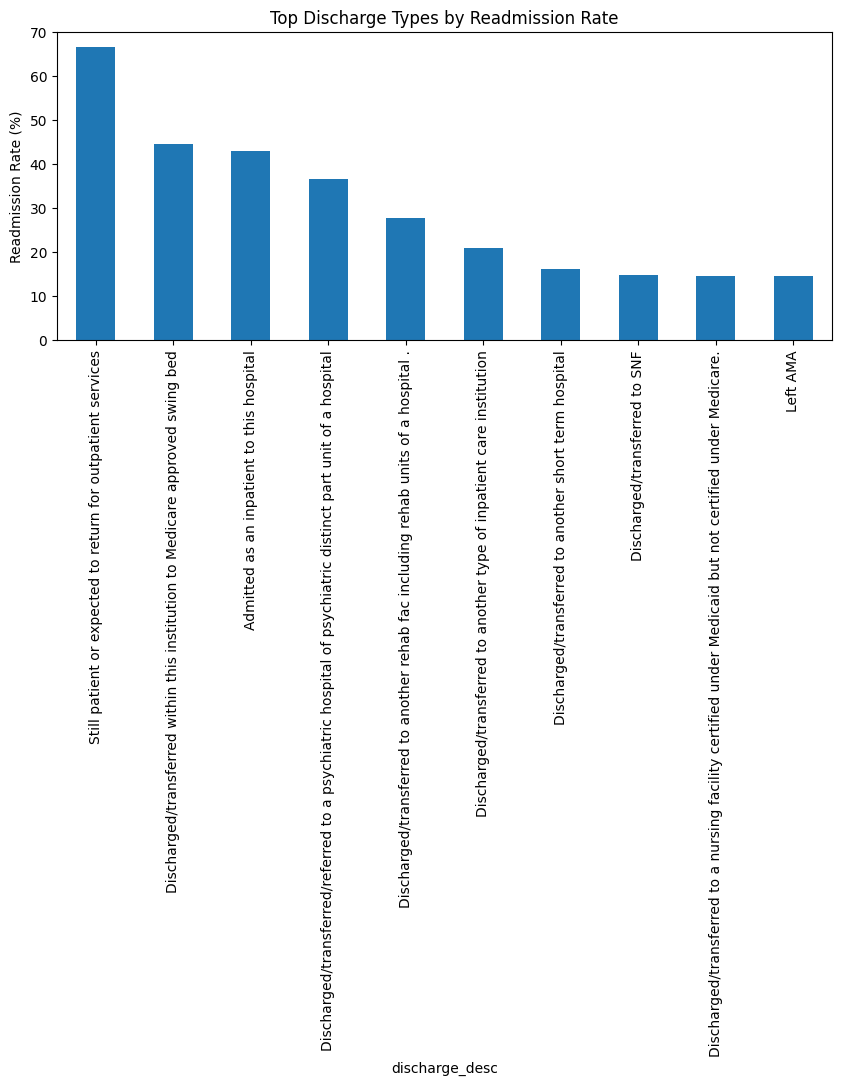

In [46]:
discharge_readmit.head(10).plot(kind='bar', figsize=(10,4))
plt.ylabel("Readmission Rate (%)")
plt.title("Top Discharge Types by Readmission Rate")
plt.show()


In [47]:
df_filtered = df[df['discharge_desc'] !=
                 'Still patient or expected to return for outpatient services']


In [48]:
df_filtered

,encounter_id,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,...,number_outpatient,number_emergency,number_inpatient,number_diagnoses,insulin,readmitted,readmitted_binary,discharge_desc,admission_type_desc,admission_source_desc
0,2278392,Caucasian,Female,[0-10),6,25,1,1,41,0,...,0,0,0,1,No,NO,0,Not Mapped,NaN,Physician Referral
1,149190,Caucasian,Female,[10-20),1,1,7,3,59,0,...,0,0,0,9,Up,>30,0,Discharged to home,Emergency,Emergency Room
2,64410,AfricanAmerican,Female,[20-30),1,1,7,2,11,5,...,2,0,1,6,No,NO,0,Discharged to home,Emergency,Emergency Room
3,500364,Caucasian,Male,[30-40),1,1,7,2,44,1,...,0,0,0,7,Up,NO,0,Discharged to home,Emergency,Emergency Room
4,16680,Caucasian,Male,[40-50),1,1,7,1,51,0,...,0,0,0,5,Steady,NO,0,Discharged to home,Emergency,Emergency Room
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
101761,443847548,AfricanAmerican,Male,[70-80),1,3,7,3,51,0,...,0,0,0,9,Down,>30,0,Discharged/transferred to SNF,Emergency,Emergency Room
101762,443847782,AfricanAmerican,Female,[80-90),1,4,5,5,33,3,...,0,0,1,9,Steady,NO,0,Discharged/transferred to ICF,Emergency,Transfer from a Skilled Nursing Facility (SNF)
101763,443854148,Caucasian,Male,[70-80),1,1,7,1,53,0,...,1,0,0,13,Down,NO,0,Discharged to home,Emergency,Emergency Room
101764,443857166,Caucasian,Female,[80-90),2,3,7,10,45,2,...,0,0,1,9,Up,NO,0,Discharged/transferred to SNF,Urgent,Emergency Room


In [49]:
df_filtered[df_filtered['discharge_desc']=='still patient or expected to return for outpatient services']

,encounter_id,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,...,number_outpatient,number_emergency,number_inpatient,number_diagnoses,insulin,readmitted,readmitted_binary,discharge_desc,admission_type_desc,admission_source_desc


In [50]:
df

,encounter_id,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,...,number_outpatient,number_emergency,number_inpatient,number_diagnoses,insulin,readmitted,readmitted_binary,discharge_desc,admission_type_desc,admission_source_desc
0,2278392,Caucasian,Female,[0-10),6,25,1,1,41,0,...,0,0,0,1,No,NO,0,Not Mapped,NaN,Physician Referral
1,149190,Caucasian,Female,[10-20),1,1,7,3,59,0,...,0,0,0,9,Up,>30,0,Discharged to home,Emergency,Emergency Room
2,64410,AfricanAmerican,Female,[20-30),1,1,7,2,11,5,...,2,0,1,6,No,NO,0,Discharged to home,Emergency,Emergency Room
3,500364,Caucasian,Male,[30-40),1,1,7,2,44,1,...,0,0,0,7,Up,NO,0,Discharged to home,Emergency,Emergency Room
4,16680,Caucasian,Male,[40-50),1,1,7,1,51,0,...,0,0,0,5,Steady,NO,0,Discharged to home,Emergency,Emergency Room
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
101761,443847548,AfricanAmerican,Male,[70-80),1,3,7,3,51,0,...,0,0,0,9,Down,>30,0,Discharged/transferred to SNF,Emergency,Emergency Room
101762,443847782,AfricanAmerican,Female,[80-90),1,4,5,5,33,3,...,0,0,1,9,Steady,NO,0,Discharged/transferred to ICF,Emergency,Transfer from a Skilled Nursing Facility (SNF)
101763,443854148,Caucasian,Male,[70-80),1,1,7,1,53,0,...,1,0,0,13,Down,NO,0,Discharged to home,Emergency,Emergency Room
101764,443857166,Caucasian,Female,[80-90),2,3,7,10,45,2,...,0,0,1,9,Up,NO,0,Discharged/transferred to SNF,Urgent,Emergency Room


In [51]:
df['age_group'] = df['age'].str.strip('[]()')


In [52]:
df.head(3)

,encounter_id,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,...,number_emergency,number_inpatient,number_diagnoses,insulin,readmitted,readmitted_binary,discharge_desc,admission_type_desc,admission_source_desc,age_group
0,2278392,Caucasian,Female,[0-10),6,25,1,1,41,0,...,0,0,1,No,NO,0,Not Mapped,NaN,Physician Referral,0-10
1,149190,Caucasian,Female,[10-20),1,1,7,3,59,0,...,0,0,9,Up,>30,0,Discharged to home,Emergency,Emergency Room,10-20
2,64410,AfricanAmerican,Female,[20-30),1,1,7,2,11,5,...,0,1,6,No,NO,0,Discharged to home,Emergency,Emergency Room,20-30


In [53]:
pd.crosstab(df['age_group'], df['readmitted_binary'], normalize='index')


readmitted_binary,0,1
age_group,,
0-10,0.981366,0.018634
10-20,0.942113,0.057887
20-30,0.857574,0.142426
30-40,0.887682,0.112318
40-50,0.893960,0.106040
50-60,0.903338,0.096662
60-70,0.888716,0.111284
70-80,0.882269,0.117731
80-90,0.879165,0.120835


Readmission rate by age

In [54]:
age_readmit = (
        df.groupby('age_group')['readmitted_binary'].mean().sort_values(ascending=False) * 100
)

In [55]:
age_readmit

age_group
20-30     14.242607
80-90     12.083503
70-80     11.773055
30-40     11.231788
60-70     11.128408
90-100    11.099177
40-50     10.604027
50-60      9.666203
10-20      5.788712
0-10       1.863354
Name: readmitted_binary, dtype: float64

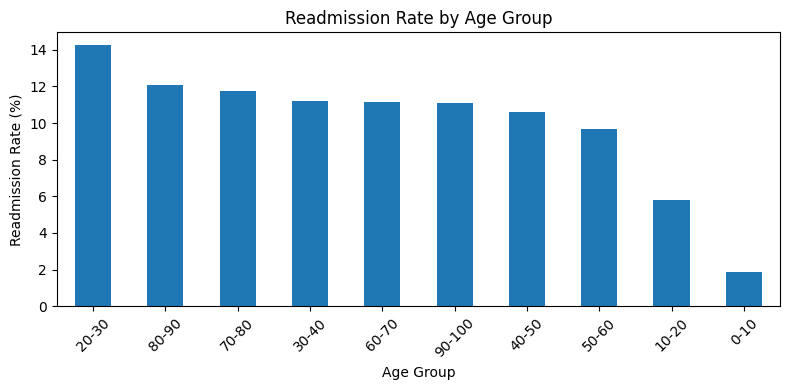

In [56]:

plt.figure(figsize=(8,4))
age_readmit.plot(kind='bar')
plt.xlabel('Age Group')
plt.ylabel('Readmission Rate (%)')
plt.title('Readmission Rate by Age Group')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [57]:
days_readmit = (
        df.groupby('time_in_hospital')['readmitted_binary'].mean().sort_values(ascending=False) * 100
)

In [58]:
days_readmit

time_in_hospital
10    14.346712
8     14.233660
9     13.724184
12    13.328729
14    12.955854
7     12.834955
6     12.587876
13    12.314050
5     12.030905
4     11.806952
3     10.666817
11    10.512129
2      9.939619
1      8.178491
Name: readmitted_binary, dtype: float64

In [59]:
df['diagnosis_group'] = pd.cut(
    df['number_diagnoses'],
    bins=[0, 2, 4, 6, 8, 10, 20],
    labels=['1–2', '3–4', '5–6', '7–8', '9–10', '11+']
)


In [60]:
df['diagnosis_group']

0          1–2
1         9–10
2          5–6
3          7–8
4          5–6
          ... 
101761    9–10
101762    9–10
101763     11+
101764    9–10
101765    9–10
Name: diagnosis_group, Length: 101766, dtype: category
Categories (6, str): ['1–2' < '3–4' < '5–6' < '7–8' < '9–10' < '11+']

In [61]:
df

,encounter_id,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,...,number_inpatient,number_diagnoses,insulin,readmitted,readmitted_binary,discharge_desc,admission_type_desc,admission_source_desc,age_group,diagnosis_group
0,2278392,Caucasian,Female,[0-10),6,25,1,1,41,0,...,0,1,No,NO,0,Not Mapped,NaN,Physician Referral,0-10,1–2
1,149190,Caucasian,Female,[10-20),1,1,7,3,59,0,...,0,9,Up,>30,0,Discharged to home,Emergency,Emergency Room,10-20,9–10
2,64410,AfricanAmerican,Female,[20-30),1,1,7,2,11,5,...,1,6,No,NO,0,Discharged to home,Emergency,Emergency Room,20-30,5–6
3,500364,Caucasian,Male,[30-40),1,1,7,2,44,1,...,0,7,Up,NO,0,Discharged to home,Emergency,Emergency Room,30-40,7–8
4,16680,Caucasian,Male,[40-50),1,1,7,1,51,0,...,0,5,Steady,NO,0,Discharged to home,Emergency,Emergency Room,40-50,5–6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
101761,443847548,AfricanAmerican,Male,[70-80),1,3,7,3,51,0,...,0,9,Down,>30,0,Discharged/transferred to SNF,Emergency,Emergency Room,70-80,9–10
101762,443847782,AfricanAmerican,Female,[80-90),1,4,5,5,33,3,...,1,9,Steady,NO,0,Discharged/transferred to ICF,Emergency,Transfer from a Skilled Nursing Facility (SNF),80-90,9–10
101763,443854148,Caucasian,Male,[70-80),1,1,7,1,53,0,...,0,13,Down,NO,0,Discharged to home,Emergency,Emergency Room,70-80,11+
101764,443857166,Caucasian,Female,[80-90),2,3,7,10,45,2,...,1,9,Up,NO,0,Discharged/transferred to SNF,Urgent,Emergency Room,80-90,9–10


In [62]:
diagnosis_readmit = (
    df.groupby('diagnosis_group')['readmitted_binary']
      .mean()
      .mul(100)
      .rename('Readmission Rate (%)')
)


In [63]:
diagnosis_readmit

diagnosis_group
1–2      6.038647
3–4      7.955088
5–6      9.747611
7–8     11.295159
9–10    12.382049
11+     14.285714
Name: Readmission Rate (%), dtype: float64

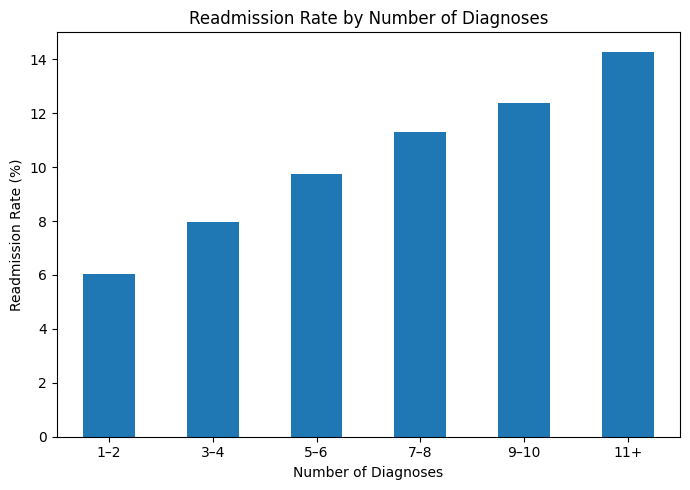

In [64]:
plt.figure(figsize=(7,5))
diagnosis_readmit.plot(kind='bar')
plt.xlabel('Number of Diagnoses')
plt.ylabel('Readmission Rate (%)')
plt.title('Readmission Rate by Number of Diagnoses')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


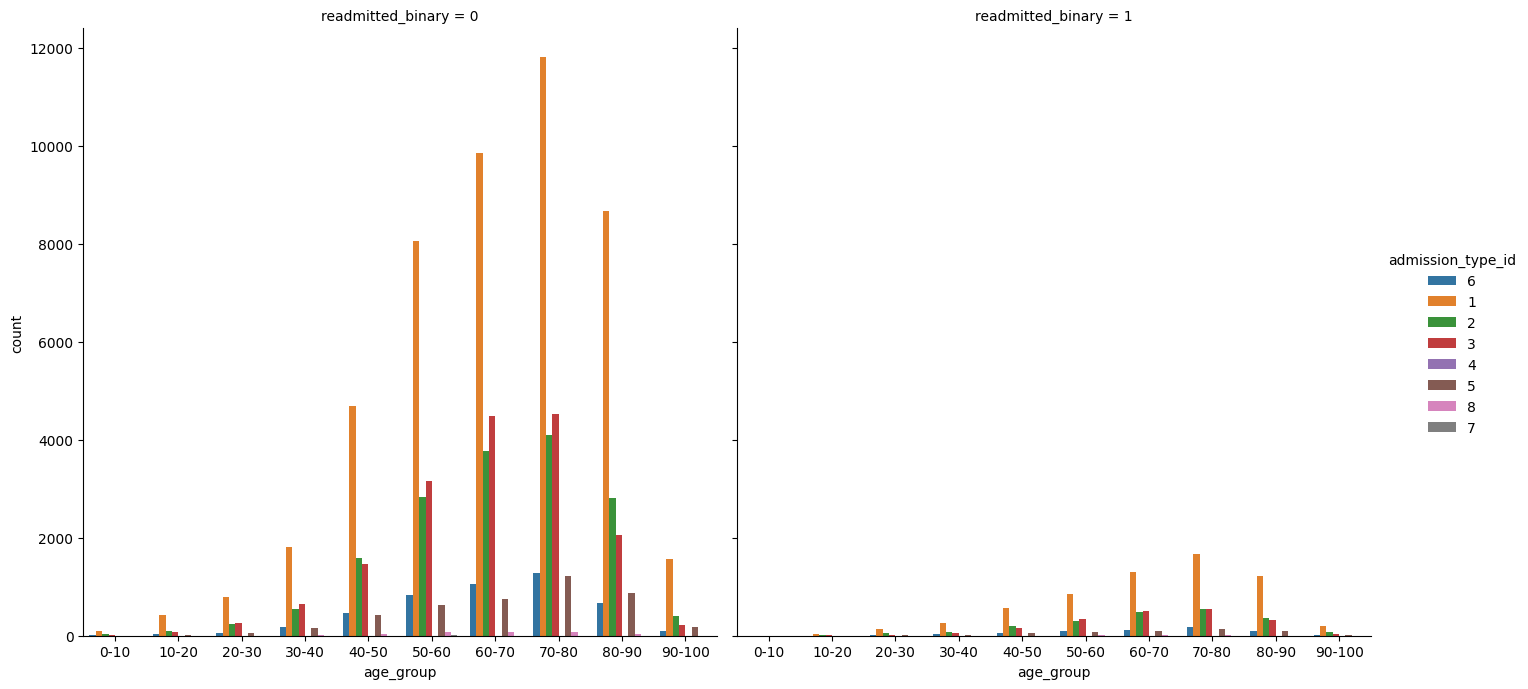

In [65]:
sb.catplot(
    x='age_group', hue='admission_type_id', col='readmitted_binary',
    kind='count', data=df, height=7, aspect=1
)

In [66]:
df

,encounter_id,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,...,number_inpatient,number_diagnoses,insulin,readmitted,readmitted_binary,discharge_desc,admission_type_desc,admission_source_desc,age_group,diagnosis_group
0,2278392,Caucasian,Female,[0-10),6,25,1,1,41,0,...,0,1,No,NO,0,Not Mapped,NaN,Physician Referral,0-10,1–2
1,149190,Caucasian,Female,[10-20),1,1,7,3,59,0,...,0,9,Up,>30,0,Discharged to home,Emergency,Emergency Room,10-20,9–10
2,64410,AfricanAmerican,Female,[20-30),1,1,7,2,11,5,...,1,6,No,NO,0,Discharged to home,Emergency,Emergency Room,20-30,5–6
3,500364,Caucasian,Male,[30-40),1,1,7,2,44,1,...,0,7,Up,NO,0,Discharged to home,Emergency,Emergency Room,30-40,7–8
4,16680,Caucasian,Male,[40-50),1,1,7,1,51,0,...,0,5,Steady,NO,0,Discharged to home,Emergency,Emergency Room,40-50,5–6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
101761,443847548,AfricanAmerican,Male,[70-80),1,3,7,3,51,0,...,0,9,Down,>30,0,Discharged/transferred to SNF,Emergency,Emergency Room,70-80,9–10
101762,443847782,AfricanAmerican,Female,[80-90),1,4,5,5,33,3,...,1,9,Steady,NO,0,Discharged/transferred to ICF,Emergency,Transfer from a Skilled Nursing Facility (SNF),80-90,9–10
101763,443854148,Caucasian,Male,[70-80),1,1,7,1,53,0,...,0,13,Down,NO,0,Discharged to home,Emergency,Emergency Room,70-80,11+
101764,443857166,Caucasian,Female,[80-90),2,3,7,10,45,2,...,1,9,Up,NO,0,Discharged/transferred to SNF,Urgent,Emergency Room,80-90,9–10


1I handled Excel auto-type coercion issues by cleaning categorical ranges and enforcing safe encodings before database ingestion.”

In [67]:
df['diagnosis_group'] = (
    df['diagnosis_group']
    .str.replace('–', '_', regex=False)
)

df.to_csv(
    "C:/Users/njdes/Downloads/hospital.csv",
    index=False,
    encoding="utf-8-sig"
)


In [68]:
df.head()


,encounter_id,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,...,number_inpatient,number_diagnoses,insulin,readmitted,readmitted_binary,discharge_desc,admission_type_desc,admission_source_desc,age_group,diagnosis_group
0,2278392,Caucasian,Female,[0-10),6,25,1,1,41,0,...,0,1,No,NO,0,Not Mapped,NaN,Physician Referral,0-10,1_2
1,149190,Caucasian,Female,[10-20),1,1,7,3,59,0,...,0,9,Up,>30,0,Discharged to home,Emergency,Emergency Room,10-20,9_10
2,64410,AfricanAmerican,Female,[20-30),1,1,7,2,11,5,...,1,6,No,NO,0,Discharged to home,Emergency,Emergency Room,20-30,5_6
3,500364,Caucasian,Male,[30-40),1,1,7,2,44,1,...,0,7,Up,NO,0,Discharged to home,Emergency,Emergency Room,30-40,7_8
4,16680,Caucasian,Male,[40-50),1,1,7,1,51,0,...,0,5,Steady,NO,0,Discharged to home,Emergency,Emergency Room,40-50,5_6


In [69]:
df.iloc[249]

encounter_id                        2913624
race                        AfricanAmerican
gender                               Female
age                                 [10-20)
admission_type_id                         6
discharge_disposition_id                 25
admission_source_id                       7
time_in_hospital                          1
num_lab_procedures                       36
num_procedures                            0
num_medications                           1
number_outpatient                         0
number_emergency                          0
number_inpatient                          0
number_diagnoses                          2
insulin                                  No
readmitted                               NO
readmitted_binary                         0
discharge_desc                   Not Mapped
admission_type_desc                     NaN
admission_source_desc        Emergency Room
age_group                             10-20
diagnosis_group                 

In [70]:
df = df.drop(columns=['age'])


In [71]:
df.replace("?",np.nan,inplace=True)

,encounter_id,race,gender,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,...,number_inpatient,number_diagnoses,insulin,readmitted,readmitted_binary,discharge_desc,admission_type_desc,admission_source_desc,age_group,diagnosis_group
0,2278392,Caucasian,Female,6,25,1,1,41,0,1,...,0,1,No,NO,0,Not Mapped,NaN,Physician Referral,0-10,1_2
1,149190,Caucasian,Female,1,1,7,3,59,0,18,...,0,9,Up,>30,0,Discharged to home,Emergency,Emergency Room,10-20,9_10
2,64410,AfricanAmerican,Female,1,1,7,2,11,5,13,...,1,6,No,NO,0,Discharged to home,Emergency,Emergency Room,20-30,5_6
3,500364,Caucasian,Male,1,1,7,2,44,1,16,...,0,7,Up,NO,0,Discharged to home,Emergency,Emergency Room,30-40,7_8
4,16680,Caucasian,Male,1,1,7,1,51,0,8,...,0,5,Steady,NO,0,Discharged to home,Emergency,Emergency Room,40-50,5_6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
101761,443847548,AfricanAmerican,Male,1,3,7,3,51,0,16,...,0,9,Down,>30,0,Discharged/transferred to SNF,Emergency,Emergency Room,70-80,9_10
101762,443847782,AfricanAmerican,Female,1,4,5,5,33,3,18,...,1,9,Steady,NO,0,Discharged/transferred to ICF,Emergency,Transfer from a Skilled Nursing Facility (SNF),80-90,9_10
101763,443854148,Caucasian,Male,1,1,7,1,53,0,9,...,0,13,Down,NO,0,Discharged to home,Emergency,Emergency Room,70-80,11+
101764,443857166,Caucasian,Female,2,3,7,10,45,2,21,...,1,9,Up,NO,0,Discharged/transferred to SNF,Urgent,Emergency Room,80-90,9_10


In [72]:
df.isnull().sum()

encounter_id                   0
race                           0
gender                         0
admission_type_id              0
discharge_disposition_id       0
admission_source_id            0
time_in_hospital               0
num_lab_procedures             0
num_procedures                 0
num_medications                0
number_outpatient              0
number_emergency               0
number_inpatient               0
number_diagnoses               0
insulin                        0
readmitted                     0
readmitted_binary              0
discharge_desc              3691
admission_type_desc         5291
admission_source_desc       6781
age_group                      0
diagnosis_group                0
dtype: int64

In [73]:
df.to_csv(
    "C:/Users/njdes/Downloads/hospital.csv",
    index=False,
    encoding="utf-8-sig"
)

In [74]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 22 columns):
 #   Column                    Non-Null Count   Dtype
---  ------                    --------------   -----
 0   encounter_id              101766 non-null  int64
 1   race                      101766 non-null  str  
 2   gender                    101766 non-null  str  
 3   admission_type_id         101766 non-null  str  
 4   discharge_disposition_id  101766 non-null  str  
 5   admission_source_id       101766 non-null  str  
 6   time_in_hospital          101766 non-null  int64
 7   num_lab_procedures        101766 non-null  int64
 8   num_procedures            101766 non-null  int64
 9   num_medications           101766 non-null  int64
 10  number_outpatient         101766 non-null  int64
 11  number_emergency          101766 non-null  int64
 12  number_inpatient          101766 non-null  int64
 13  number_diagnoses          101766 non-null  int64
 14  insulin                   10176